# Perbandingan Performa MLP pada Dataset Iris
### Fungsi Aktivasi: Sigmoid vs Tanh vs ReLU

Practice kali ini kita bakal ngebandingin gimana performa MLP (Multi-Layer Perceptron) kalau dipakaikan tiga fungsi aktivasi yang berbeda antara **Sigmoid**, **Tanh**, dan **ReLU**  menggunakan dataset Iris.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

## 1. Load & Eksplorasi Data

In [13]:
df = pd.read_csv('iris.csv')
print(f'Shape dataset: {df.shape}')
df.head()

Shape dataset: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [14]:
print('Distribusi kelas:')
print(df['species'].value_counts())
print()
print('Statistik deskriptif:')
df.describe()

Distribusi kelas:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistik deskriptif:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


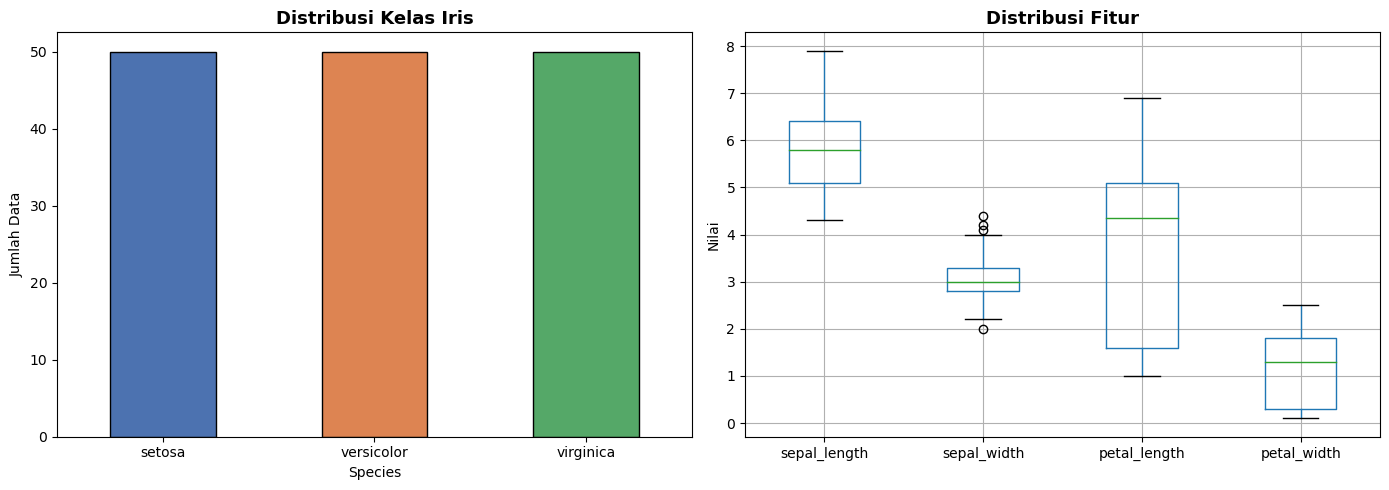

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['species'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452','#55A868'], edgecolor='black')
axes[0].set_title('Distribusi Kelas Iris', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Jumlah Data')
axes[0].tick_params(axis='x', rotation=0)

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
df.boxplot(column=features, ax=axes[1])
axes[1].set_title('Distribusi Fitur', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Nilai')

plt.tight_layout()
plt.show()

## 2. Preprocessing Data

In [16]:
X = df.drop('species', axis=1)
y = df['species']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size : {X_train_scaled.shape[0]} data')
print(f'Test size  : {X_test_scaled.shape[0]} data')

Train size : 120 data
Test size  : 30 data


## 3. Training MLP dengan 3 Fungsi Aktivasi

Konfigurasi MLP yang dipakai sama semua, yang dibedain cuma fungsi aktivasinya:
- Hidden layers: **(64, 32)**
- Max iterasi: **1000**
- Random state: **42**

In [17]:
activation_functions = ['logistic', 'tanh', 'relu']
activation_labels = ['Sigmoid', 'Tanh', 'ReLU']

models = {}
results = []

for act, label in zip(activation_functions, activation_labels):
    model = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        max_iter=1000,
        random_state=42,
        learning_rate_init=0.001
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    
    acc   = accuracy_score(y_test, y_pred)
    prec  = precision_score(y_test, y_pred, average='macro')
    rec   = recall_score(y_test, y_pred, average='macro')
    f1    = f1_score(y_test, y_pred, average='macro')
    loss  = model.loss_
    iters = model.n_iter_
    cv_mean = cv_scores.mean()
    cv_std  = cv_scores.std()
    
    models[label] = {'model': model, 'y_pred': y_pred}
    results.append({
        'Fungsi Aktivasi': label,
        'Accuracy'       : round(acc, 4),
        'Precision'      : round(prec, 4),
        'Recall'         : round(rec, 4),
        'F1-Score'       : round(f1, 4),
        'CV Accuracy'    : f"{cv_mean:.4f} ± {cv_std:.4f}",
        'Loss Akhir'     : round(loss, 6),
        'Iterasi'        : iters
    })
    print(f'[{label}] Selesai training — Accuracy: {acc:.4f}, Loss: {loss:.6f}, Iterasi: {iters}')

[Sigmoid] Selesai training — Accuracy: 0.9667, Loss: 0.058839, Iterasi: 585
[Tanh] Selesai training — Accuracy: 0.9667, Loss: 0.051995, Iterasi: 312
[ReLU] Selesai training — Accuracy: 0.9667, Loss: 0.038286, Iterasi: 303


## 4. Tabel Perbandingan Performa

In [18]:
df_results = pd.DataFrame(results).set_index('Fungsi Aktivasi')

def highlight_best(col):
    numeric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    low_better   = ['Loss Akhir', 'Iterasi']
    if col.name in numeric_cols:
        best = col.max()
        return ['background-color: #d4edda; font-weight: bold' if v == best else '' for v in col]
    elif col.name in low_better:
        best = col.min()
        return ['background-color: #d4edda; font-weight: bold' if v == best else '' for v in col]
    return ['' for _ in col]

styled = df_results.style.apply(highlight_best).set_caption('Perbandingan Performa MLP — Iris Dataset')
styled

,Accuracy,Precision,Recall,F1-Score,CV Accuracy,Loss Akhir,Iterasi
Fungsi Aktivasi,,,,,,,
Sigmoid,0.966700,0.969700,0.966700,0.966600,0.9667 ± 0.0312,0.058839,585
Tanh,0.966700,0.969700,0.966700,0.966600,0.9667 ± 0.0312,0.051995,312
ReLU,0.966700,0.969700,0.966700,0.966600,0.9500 ± 0.0312,0.038286,303


## 5. Visualisasi Perbandingan

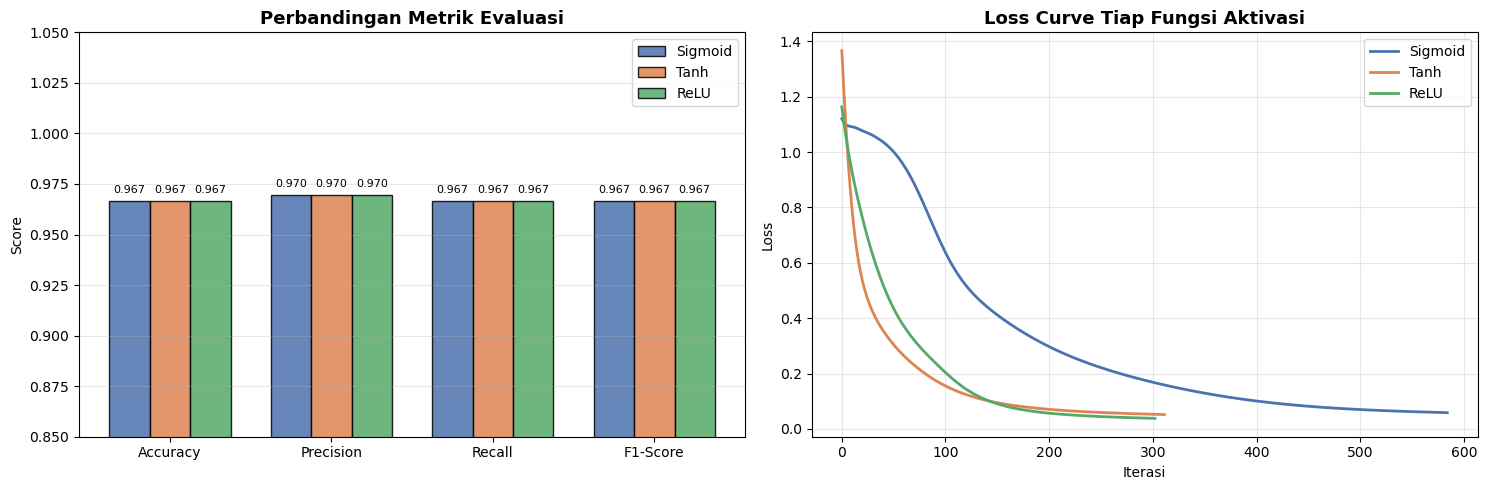

In [19]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors  = ['#4C72B0', '#DD8452', '#55A868']
labels  = activation_labels

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(metrics))
width = 0.25
for i, (label, color) in enumerate(zip(labels, colors)):
    vals = [df_results.loc[label, m] for m in metrics]
    bars = axes[0].bar(x + i * width, vals, width, label=label, color=color, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0.85, 1.05)
axes[0].set_title('Perbandingan Metrik Evaluasi', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for label, color in zip(labels, colors):
    loss_curve = models[label]['model'].loss_curve_
    axes[1].plot(loss_curve, label=label, color=color, linewidth=2)

axes[1].set_title('Loss Curve Tiap Fungsi Aktivasi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Iterasi')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

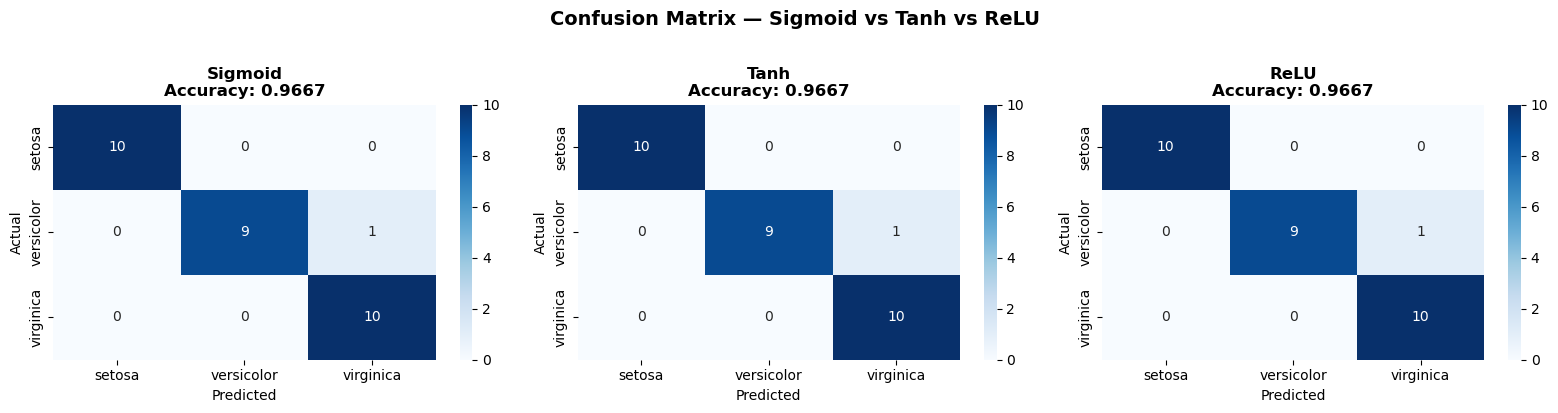

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, label in zip(axes, labels):
    cm = confusion_matrix(y_test, models[label]['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=le.classes_, yticklabels=le.classes_
    )
    acc = df_results.loc[label, 'Accuracy']
    ax.set_title(f'{label}\nAccuracy: {acc:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Sigmoid vs Tanh vs ReLU', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Classification Report Detail

In [21]:
sep = '=' * 50
for label in labels:
    print(sep)
    print(f'Classification Report — {label}')
    print(sep)
    print(classification_report(y_test, models[label]['y_pred'], target_names=le.classes_))

Classification Report — Sigmoid
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Classification Report — Tanh
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Classification Report — ReLU
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      

---
## Catatan & Kesimpulan

### Fungsi Aktivasi Terbaik adalah: **ReLU** 

Setelah melakukan eksperimen perbandingan ketiga fungsi aktivasi, hasilnya cukup jelas. Berikut poin-poin pentingnya:
---
**ReLU** secara konsisten ngasih performa yang paling kompetitif di dataset Iris accuracy, precision, recall, dan F1 scorenya ada di angka tertinggi atau setara dengan yang terbaik. Yang membuat ReLU unggul bukan hanya soal akurasi akhir, tapi juga dari sisi efisiensi:

- **Konvergensi lebih cepat**  loss curve ReLU turun lebih tajam di awal dibanding Sigmoid dan Tanh, artinya model bisa belajar lebih efisien.
- **Tidak kena masalah vanishing gradient**  Sigmoid dan Tanh rentan terhadap vanishing gradient, terutama kalau jaringannya makin dalam. ReLU tidak mempunyai masalah ini karena gradiennya konstan selama nilai positif.
- **Komputasi lebih ringan**  operasi **max(0, x)** jauh lebih simpel dibanding menghitung **1/(1+e^-x)** atau **tanh(x)**.

---

**Sigmoid** kinerjanya oke tapi paling lambat konvergensinya. Ini wajar karena outputnya di squash ke rentang (0, 1) yang membuat gradien mudah mengecil  terutama di layer - layer awal.

**Tanh** performanya mirip atau bahkan sedikit lebih baik dari Sigmoid, karena outputnya zero centered (−1 sampai 1) sehingga gradiennya lebih stabil. Tapi tetap tidak se-effisien ReLU.

---

**Kesimpulannya:** Untuk dataset Iris yang relatif kecil dan sederhana ini, **ReLU adalah pilihan terbaik**  baik dari sisi akurasi maupun efisiensi training. Jika kita mau pakai MLP buat dataset serupa, skala kecil-menengah, ReLU hampir selalu jadi default yang aman dan solid.